# Exploring a family tree as a graph

This is the first pass at ideas for gedcom-toolkit -- poking at a parsed
GEDCOM file before anything here gets solidified into a tested CLI command.

The GEDCOM file used here is `data/sample/sample.ged`, a small synthetic
five-person tree that ships with the repo. To point this at a real research
file instead, change `GEDCOM_PATH` below to a file under `data/private/`
(gitignored, never committed) -- everything after that cell works the same
regardless of file size.

The core idea I keep coming back to: a family tree is a directed graph.
Parent -> child edges capture descent. Once it's in that shape, questions
like "how many generations deep does this go?" or "who has the most
undiscovered descendants?" become graph-traversal questions, not manual
counting.

In [4]:
from pathlib import Path
from collections import Counter

import networkx as nx
import matplotlib.pyplot as plt

from gedcomtoolkit.parser import parse_gedcom
from gedcomtoolkit.graph import build_graph

GEDCOM_PATH = Path("../data/private/Thompson.ged")

tree = parse_gedcom(GEDCOM_PATH)
g = build_graph(tree)

print(f"Loaded {GEDCOM_PATH}")
print(f"{len(tree.individuals)} individuals, {len(tree.families)} families")

Loaded ../data/private/Thompson.ged
931 individuals, 276 families


## Basic shape of the data

Before anything graph-specific, worth just looking at what came out of the
parser. `tree.individuals` and `tree.families` are plain dicts of the
dataclasses from `gedcomtoolkit.models` -- keyed by their GEDCOM xref_id
(e.g. `@I1@`), which is the same identifier used as a node ID in the graph.

In [5]:
for indi in tree.individuals.values():
    print(
        f"{indi.xref_id:6} {indi.full_name:20} "
        f"b.{indi.birth_date or '?':14} d.{indi.death_date or 'living'}"
    )

@I1@   Steven Thompson      b.30 JUN 1970    d.living
@I2@   Bryan Stanley Thompson b.13 MAR 1942    d.living
@I3@   Gwendoline Joyce Whitmore b.30 APR 1945    d.living
@I4@   Arthur Stanley Thompson b.24 JUN 1914    d.12 APR 2004
@I5@   Dorothy Mary Toone   b.6 MAY 1924     d.18 JUN 2009
@I6@   Emma Thompson        b.26 MAR 1976    d.living
@I7@   Margaret Julia Hines b.29 NOV 1883    d.living
@I8@   Robert Richard Toone b.1871           d.22 JUN 1935
@I9@   Robert John Toone    b.1912           d.2 JUN 1956
@I10@  Ernest Arthur Toone  b.23 JUN 1913    d.30 DEC 1998
@I11@  Edmund William Toone b.22 MAY 1920    d.living
@I12@  John Taylor Hines    b.20 AUG 1855    d.living
@I13@  Elizabeth Munden     b.6 MAY 1854     d.living
@I14@  Francis Isaac Hines  b.30 JAN 1884    d.living
@I15@  Christopher Martin Harmsworth b.13 MAY 1963    d.living
@I16@  George Henry Hines   b.18 DEC 1885    d.living
@I17@  John Reginald Hines  b.3 DEC 1890     d.living
@I18@  Arthur Edward Hines  b.?        

## Missing data

This is the question `gedcom rn` ("research next") will eventually need to
answer at scale: how much is missing, and whose gaps matter most?

Two easy signals to start with: no birth date recorded, and no parents
linked (`family_as_child` is `None` -- either a genuine root ancestor, or
a broken link).

In [6]:
n = len(tree.individuals)
missing_birth = [i for i in tree.individuals.values() if not i.birth_date]
missing_death_but_old = [
    i for i in tree.individuals.values()
    if not i.death_date and i.birth_date  # "presumed living" from stats command
]
no_parents_linked = [i for i in tree.individuals.values() if not i.family_as_child]

print(f"Missing birth date:      {len(missing_birth)}/{n} ({len(missing_birth)/n:.0%})")
print(f"No parents linked:       {len(no_parents_linked)}/{n} ({len(no_parents_linked)/n:.0%})")
print()
print("No parents linked (candidates for further research, or just tree roots):")
for i in no_parents_linked:
    print(f"  {i.full_name}")

Missing birth date:      473/931 (51%)
No parents linked:       311/931 (33%)

No parents linked (candidates for further research, or just tree roots):
  Lucy Unknown
  John Holloway
  Lilian Hobley
  Donald Tisor
  Constance Clark
  Unknown Smith
  James Duffy
  Geraldine Unknown
  Bridget Mangan
  John Lello
  Peter Phillips
  Paul McArdle
  Susan Unknown
  Maureen Hooper
  Robert Hutchinson
  Carol Pinks
  Sue Turton
  George Hindess
  Barbara Unknown
  Norman Hopcraft
  Hugh Stapleton Perkins
  Kath Unknown
  Peggy Unknown
  Elizabeth Branson
  Albert Wright
  William Gorring
  William Todd
  Len Buckingham
  Annie Phillips
  Johann Ona
  Mary Ann Williams
  Albert Edward Baker
  Harold Kilvington
  Albert Edward Blake
  George Skeels
  Caroline Jane Clark
  Unknown Sutton
  Unknown Hubbard
  James Thompson
  William Rogers
  Ann Harris
  Robert Kingston
  Lynn Unknown
  Norman Emery
  Marie Unknown
  Donna Wade
  June Bass
  Gail Unknown
  Frances Unknown
  Clair Unknown
  Jacquel

On a five-person toy file, "no parents linked" mostly just means "this is
the oldest generation I have" -- expected, not a problem. On a real file
with hundreds of people, the same query separates genuine brick walls from
data-entry gaps, which is exactly the distinction `gedcom rn` needs to make
before it can weight anyone.

## Connectivity: is this actually one tree?

GEDCOM files -- especially ones assembled from multiple sources, or with
old broken links -- often aren't one connected tree at all. They're several
disconnected clusters that happen to live in the same file. `networkx` calls
these weakly connected components (weak = ignoring edge direction, since I
want to know "is there any path at all between these two people", not
specifically a descent path).

In [7]:
components = list(nx.weakly_connected_components(g))
sizes = sorted((len(c) for c in components), reverse=True)

print(f"{len(components)} component(s), sizes: {sizes}")

if len(components) > 1:
    print()
    print("More than one cluster -- worth checking whether that's expected")
    print("(e.g. two unrelated family lines) or a broken FAMC/FAMS link.")

39 component(s), sizes: [797, 12, 12, 9, 9, 9, 7, 6, 5, 5, 5, 4, 4, 4, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

More than one cluster -- worth checking whether that's expected
(e.g. two unrelated family lines) or a broken FAMC/FAMS link.


## How deep does this go? (generation depth)

Restricting to parent -> child edges only (dropping the spouse edges),
the longest path from any root ancestor down to any descendant tells me
how many generations the file actually covers. `networkx.dag_longest_path`
does this directly, since the parent-only subgraph is a DAG as long as the
data doesn't contain a cycle (someone recorded as their own ancestor --
which is itself a data error worth flagging, and exactly the kind of check
`gedcom validate` should do).

In [5]:
parent_edges = [
    (u, v) for u, v, d in g.edges(data=True) if d["relation"] == "parent"
]
parent_graph = nx.DiGraph(parent_edges)
parent_graph.add_nodes_from(g.nodes())  # keep isolated nodes in the count

is_dag = nx.is_directed_acyclic_graph(parent_graph)
print(f"Parent-only graph is a DAG: {is_dag}")

if is_dag:
    longest = nx.dag_longest_path(parent_graph)
    names = [tree.get_individual(xref_id).full_name for xref_id in longest]
    print(f"Longest chain ({len(longest)} people, {len(longest) - 1} generations):")
    print("  " + " -> ".join(names))
else:
    cycle = nx.find_cycle(parent_graph)
    print(f"Cycle found -- data error: {cycle}")

Parent-only graph is a DAG: True
Longest chain (3 people, 2 generations):
  John Smith -> Alice Smith -> Carol Brown


## Who has the most children? (a first pass at weighting)

Out-degree on the parent-only graph is just "how many recorded children".
On a real file, cross-referencing this against `missing_birth` and
`no_parents_linked` starts to look like the scoring model `gedcom rn`
needs: someone with many children and a missing birth date is a much
higher-value research target than someone with no children and a missing
birth date, because filling in their gap unlocks a whole branch.

In [6]:
child_counts = Counter()
for u, v, d in g.edges(data=True):
    if d["relation"] == "parent":
        child_counts[u] += 1

for xref_id, count in child_counts.most_common():
    print(f"{tree.get_individual(xref_id).full_name:20} {count} child(ren)")

John Smith           1 child(ren)
Mary Jones           1 child(ren)
Alice Smith          1 child(ren)
Bob Brown            1 child(ren)


## Surnames

Quick frequency count -- on a small file this is nothing, but on a real
tree spanning centuries this is where spelling drift shows up (Smith /
Smyth / Smythe), which is what `gedcom surnames` will eventually need to
cluster rather than just count.

In [7]:
surnames = Counter(
    i.surname for i in tree.individuals.values() if i.surname
)
for surname, count in surnames.most_common():
    print(f"{surname:15} {count}")

Smith           2
Brown           2
Jones           1


## A quick visual

Nothing fancy -- spring layout, parent edges solid, spouse edges dashed.
Mainly useful as a sanity check on a small file; on a real tree this will
need a proper layered/generational layout instead (that's what
`gedcom fan` is for), since spring layout gets unreadable past a few dozen
people.

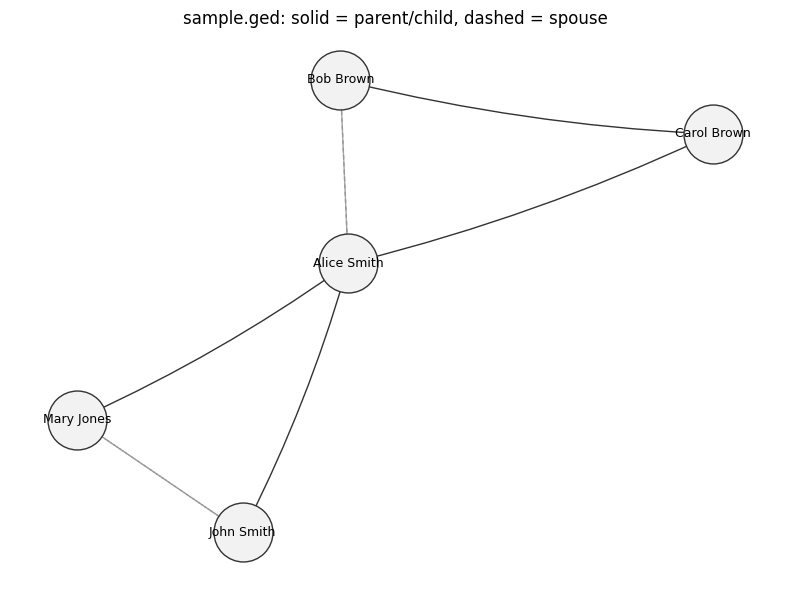

In [8]:
pos = nx.spring_layout(g, seed=42)

parent_edges = [(u, v) for u, v, d in g.edges(data=True) if d["relation"] == "parent"]
spouse_edges = [(u, v) for u, v, d in g.edges(data=True) if d["relation"] == "spouse"]

labels = {n: tree.get_individual(n).full_name for n in g.nodes()}

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

nx.draw_networkx_nodes(g, pos, node_color="#f2f2f2", edgecolors="#333333", node_size=1800, ax=ax)
nx.draw_networkx_labels(g, pos, labels, font_size=9, ax=ax)
nx.draw_networkx_edges(
    g, pos, edgelist=parent_edges, edge_color="#333333", arrows=True,
    arrowsize=15, connectionstyle="arc3,rad=0.05", ax=ax,
)
nx.draw_networkx_edges(
    g, pos, edgelist=spouse_edges, edge_color="#999999", style="dashed",
    arrows=False, ax=ax,
)

ax.set_title(f"{GEDCOM_PATH.name}: solid = parent/child, dashed = spouse")
ax.axis("off")
plt.tight_layout()
plt.show()

## What this points to for the CLI

Nothing here is a surprise, but a few things worth calling out because
they scale to a real file in a way that's obvious once you see it small:

- **`gedcom validate`** -- the cycle check above (`is_directed_acyclic_graph`
  + `find_cycle`) is basically the whole implementation already. Add
  death-before-birth and implausible-age checks alongside it.
- **`gedcom rn`** -- needs at minimum: missing birth date, no parents
  linked, and descendant count (from the child-count section) combined
  into a weighted score. The pieces are all here individually; the next
  step is combining them.
- **Component check** -- worth running before anything else on a real
  file, since a broken link silently splitting the tree in two would
  otherwise go unnoticed.
- **Layout** -- spring layout won't survive contact with a real tree.
  `gedcom fan` needs a proper generational layout (rank by distance from
  a chosen root) rather than a force-directed one.